In [1]:
# Install the pinned versions (a no-op when they're already there)
#%pip install -q --disable-pip-version-check -r requirements.txt

In [2]:
# Print how long every cell takes
%load_ext autotime

time: 98.7 μs (started: 2026-10-04 09:28:41 +05:30)


In [3]:
# One environment setting first (this kernel and every `!python` line inherit it), then the imports
import os

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"  # no download progress bars in the outputs

import json
import logging
import pickle
import time
from typing import Literal

import matplotlib.pyplot as plt
import mlflow
import optuna
import pandas as pd
import sklearn
import xgboost
from fastapi import FastAPI
from fastapi.testclient import TestClient
from mlflow import MlflowClient
from mlflow.pyfunc import scoring_server
from pydantic import BaseModel, Field
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

print(f"mlflow {mlflow.__version__} · optuna {optuna.__version__} · scikit-learn {sklearn.__version__} · "
      f"xgboost {xgboost.__version__} · pandas {pd.__version__}")

c:\Users\Sharath\.conda\envs\agents\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mlflow 3.16.1 · optuna 5.0.0 · scikit-learn 1.9.1 · xgboost 3.4.1 · pandas 3.0.6
time: 2.77 s (started: 2026-10-04 09:28:41 +05:30)


In [4]:
# Point MLflow at the store beside this notebook, and select the experiment every run goes into
mlflow.set_tracking_uri("sqlite:///mlflow.db")               # also exported as MLFLOW_TRACKING_URI: `!python train.py` logs here too
experiment = mlflow.set_experiment("booking-cancellations")  # created on first use, selected after that
client = MlflowClient()                                      # same store; P3 and P5 go through it for the registry

print("tracking URI:", mlflow.get_tracking_uri())
print("experiment  :", experiment.name, "| id", experiment.experiment_id)

tracking URI: sqlite:///mlflow.db
experiment  : booking-cancellations | id 1
time: 673 ms (started: 2026-10-04 09:28:43 +05:30)


In [5]:
# 118,300 past bookings with a known outcome: one row per booking
bookings = pd.read_csv("data/bookings_2015_2017.csv.gz")

print(f"{len(bookings):,} bookings · arrivals {bookings.arrival_date.min()} → {bookings.arrival_date.max()} · cancelled {bookings.is_canceled.mean():.1%}")
bookings.head(3)

118,300 bookings · arrivals 2015-07-01 → 2017-08-24 · cancelled 37.1%


,booking_id,arrival_date,hotel,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,is_canceled
0,BK100001,2015-07-01,City Hotel,6,0,2,1,0.0,0,HB,...,0,0,A,No Deposit,Transient,0,0.0,0,0,0
1,BK100002,2015-07-01,City Hotel,88,0,4,2,0.0,0,BB,...,0,0,A,No Deposit,Transient,0,76.5,0,1,1
2,BK100003,2015-07-01,City Hotel,65,0,4,1,0.0,0,BB,...,0,0,A,No Deposit,Transient,0,68.0,0,1,1


time: 266 ms (started: 2026-10-04 09:28:44 +05:30)


In [6]:
# The same features, dtypes and split train.py uses, so the notebook and the script see identical rows
NUMERIC = [
    "lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children",
    "babies", "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled",
    "days_in_waiting_list", "adr", "required_car_parking_spaces", "total_of_special_requests",
]
CATEGORICAL = [
    "hotel", "meal", "market_segment", "distribution_channel", "reserved_room_type",
    "deposit_type", "customer_type",
]
FEATURES = NUMERIC + CATEGORICAL
SEED = 42

X = bookings[FEATURES].astype({c: "float64" for c in NUMERIC})  # float64: see below
y = bookings["is_canceled"]
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)       # 60% train
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, stratify=y_rest, random_state=SEED)  # 20% / 20%

print(f"train {len(X_train):,} · validation {len(X_val):,} · test {len(X_test):,} · {len(FEATURES)} features")

train 70,980 · validation 23,660 · test 23,660 · 20 features
time: 137 ms (started: 2026-10-04 09:28:44 +05:30)


In [7]:
# Train today's model with train.py's defaults: one tracked run in this notebook's store
!python train.py --run-name xgb-depth6

test_roc_auc = 0.9014
tracking_uri = sqlite:///mlflow.db
run_id       = a8655fc95fe447209a7a98634c117a0b
model_uri    = models:/m-aeca01cd6fd942f2a85d020d324f1906
time: 18.6 s (started: 2026-10-04 09:28:44 +05:30)


2026/10/04 09:28:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [8]:
# The run train.py just logged, and the logged model it produced
current_run = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="attributes.run_name = 'xgb-depth6'",
    order_by=["attributes.start_time DESC"],  # newest first, in case it was trained more than once
    max_results=1,
    output_format="list",                     # Run objects instead of a DataFrame
)[0]
current_model_id = current_run.outputs.model_outputs[0].model_id  # a run lists the models it logged

print("run      :", current_run.info.run_name, "|", current_run.info.run_id)
print("test     :", {k: round(v, 4) for k, v in current_run.data.metrics.items() if k.startswith("test_")})
print("size     :", round(current_run.data.metrics["model_size_mb"], 1), "MB")
print("model URI:", f"models:/{current_model_id}")
print("output   :", mlflow.models.get_model_info(f"models:/{current_model_id}").signature.outputs)

run      : xgb-depth6 | a8655fc95fe447209a7a98634c117a0b
test     : {'test_roc_auc': 0.9014, 'test_pr_auc': 0.8737, 'test_f1': 0.7515, 'test_precision': 0.8458, 'test_recall': 0.6761}
size     : 0.9 MB
model URI: models:/m-aeca01cd6fd942f2a85d020d324f1906
output   : [Tensor('float32', (-1, 2))]
time: 82 ms (started: 2026-10-04 09:29:03 +05:30)


# Part 2

In [9]:
# The two functions train.py uses, defined here too so every trial trains and scores exactly like the script
def build_pipeline(config):
    """Preprocessing + XGBoost, set up by `config`; returns an untrained Pipeline."""
    prep = ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUMERIC),  # fill gaps, rescale
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),                         # an unseen code → all zeros
    ])
    model = XGBClassifier(
        n_estimators=config["n_estimators"],          # how many trees, each one correcting the ones before it
        learning_rate=config["learning_rate"],
        max_depth=config["max_depth"],
        min_child_weight=config["min_child_weight"],
        random_state=SEED,
    )
    return Pipeline([("prep", prep), ("model", model)])


def evaluate(pipe, X, y, prefix):
    """Ranking quality (ROC-AUC, PR-AUC) plus F1 / precision / recall at the 0.5 threshold."""
    proba = pipe.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        f"{prefix}_roc_auc": roc_auc_score(y, proba),
        f"{prefix}_pr_auc": average_precision_score(y, proba),
        f"{prefix}_f1": f1_score(y, pred),
        f"{prefix}_precision": precision_score(y, pred),
        f"{prefix}_recall": recall_score(y, pred),
    }

time: 2.29 ms (started: 2026-10-04 09:29:03 +05:30)


In [10]:
# One trial = one child run: propose a configuration, fit on train, score on validation, log it all
# Here we are using Optuna to automatically search for good XGBoost hyperparameters, while MLflow records every Optuna trial as a child run.


# Optuna = decides WHAT hyperparameters to try
# MLflow = records WHAT happened
# XGBoost = model being trained

def objective(trial): # is the function Optuna repeatedly calls during optimization.
    """Optuna calls this once per trial; the value it returns is what the study maximises."""
    #A trial means: One attempt using one specific combination of hyperparameters.
    config = {
        "model_type": "xgboost",
        "n_estimators": 300,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.3, log=True),  # log=True: sample evenly across ratios
        "max_depth": trial.suggest_int("max_depth", 3, 14),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 20, log=True),
    }
    with mlflow.start_run(run_name=f"trial-{trial.number:02d}", nested=True):  # a child of the open parent run
        mlflow.log_params(config)
        mlflow.set_tag("stage", "trial")
        start = time.time()
        pipe = build_pipeline(config).fit(X_train, y_train) 
        fit_time = time.time() - start
        metrics = evaluate(pipe, X_val, y_val, prefix="val")
        mlflow.log_metrics({**metrics, "fit_time_s": fit_time, "model_size_mb": len(pickle.dumps(pipe)) / 1e6})

    print(f"trial-{trial.number:02d}  val_roc_auc {metrics['val_roc_auc']:.4f}  {fit_time:4.1f}s  "
          f"learning_rate {config['learning_rate']:.3f}  max_depth {config['max_depth']:2d}  "
          f"min_child_weight {config['min_child_weight']:5.2f}")
    return metrics["val_roc_auc"]

time: 2.82 ms (started: 2026-10-04 09:29:03 +05:30)


trial-00  val_roc_auc 0.9086   1.5s  learning_rate 0.055  max_depth 14  min_child_weight  8.96
trial-01  val_roc_auc 0.8918   0.7s  learning_rate 0.101  max_depth  4  min_child_weight  1.60
trial-02  val_roc_auc 0.9040   1.7s  learning_rate 0.023  max_depth 13  min_child_weight  6.05
trial-03  val_roc_auc 0.8876   0.8s  learning_rate 0.136  max_depth  3  min_child_weight 18.28
trial-04  val_roc_auc 0.9024   0.9s  learning_rate 0.191  max_depth  5  min_child_weight  1.72
trial-05  val_roc_auc 0.8876   1.0s  learning_rate 0.033  max_depth  6  min_child_weight  4.82
trial-06  val_roc_auc 0.8955   1.0s  learning_rate 0.064  max_depth  6  min_child_weight  6.25
trial-07  val_roc_auc 0.8860   1.1s  learning_rate 0.029  max_depth  6  min_child_weight  3.00
trial-08  val_roc_auc 0.9108   1.7s  learning_rate 0.069  max_depth 12  min_child_weight  1.82
trial-09  val_roc_auc 0.9104   1.4s  learning_rate 0.081  max_depth 10  min_child_weight  1.15
trial-10  val_roc_auc 0.9101   1.4s  learning_rate

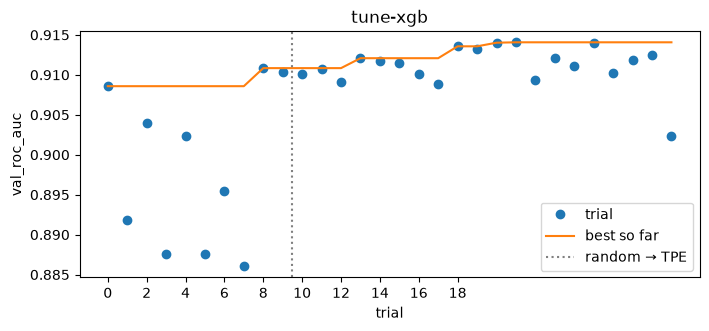

time: 53.2 s (started: 2026-10-04 09:29:27 +05:30)


In [11]:
# The search: one parent run; study.optimize() calls objective() 20 times, each call a child run inside it
optuna.logging.set_verbosity(optuna.logging.WARNING)  # objective() prints its own one-line summary per trial

with mlflow.start_run(
    run_name="tune-xgb", # parent run
    description="Optuna TPE over learning_rate, max_depth, min_child_weight; fit on train, scored on validation.",
) as tuning_run:
    mlflow.set_tag("stage", "tuning")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=30)

    best_config = {"model_type": "xgboost", "n_estimators": 300, **study.best_params}  # typed values, ready for train.py
    mlflow.log_params({"n_trials": len(study.trials), "sampler": "TPE", "seed": SEED})
    mlflow.log_metric("best_val_roc_auc", study.best_value)
    mlflow.log_dict(best_config, "best_config.json")

    history = study.trials_dataframe()  # one row per trial: its number, value and params
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.plot(history.number, history.value, "o", label="trial")
    ax.plot(history.number, history.value.cummax(), "-", label="best so far")
    ax.axvline(9.5, color="grey", linestyle=":", label="random → TPE")
    ax.set(xlabel="trial", ylabel="val_roc_auc", title="tune-xgb", xticks=range(0, 20, 2))
    ax.legend()
    mlflow.log_figure(fig, "plots/search_history.png")

tuning_run_id = tuning_run.info.run_id
print(f"\nbest: trial-{study.best_trial.number:02d} · val_roc_auc {study.best_value:.4f} · {best_config}")

In [12]:
# The trials as a leaderboard: children are found through the tag MLflow sets on them, mlflow.parentRunId
trials = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string=f"tags.mlflow.parentRunId = '{tuning_run_id}'",
    order_by=["metrics.val_roc_auc DESC"],
)

top = trials.head(6)
pd.DataFrame({
    "run": top["tags.mlflow.runName"],
    "learning_rate": top["params.learning_rate"].astype(float).round(3),  # params come back as strings
    "max_depth": top["params.max_depth"],
    "min_child_weight": top["params.min_child_weight"].astype(float).round(2),
    "val_roc_auc": top["metrics.val_roc_auc"].round(4),
    "fit_time_s": top["metrics.fit_time_s"].round(1),
    "model_size_mb": top["metrics.model_size_mb"].round(1),
})

,run,learning_rate,max_depth,min_child_weight,val_roc_auc,fit_time_s,model_size_mb
0,trial-21,0.091,14,1.24,0.9141,2.1,7.2
1,trial-25,0.101,12,1.01,0.9140,1.7,5.0
2,trial-20,0.117,14,1.02,0.9140,2.1,7.8
3,trial-18,0.143,12,1.03,0.9136,1.8,5.4
4,trial-19,0.091,14,1.22,0.9132,2.1,7.4
5,trial-28,0.089,14,2.34,0.9125,1.8,5.4


time: 124 ms (started: 2026-10-04 09:33:49 +05:30)


In [13]:
!python train.py --config runs:/$tuning_run_id/best_config.json --run-name xgb-tuned

test_roc_auc = 0.9187
tracking_uri = sqlite:///mlflow.db
run_id       = 140631355d2a43978390cfa35fc846e4
model_uri    = models:/m-ab5f301ffc384b2688c398872761d490
time: 20.3 s (started: 2026-10-04 09:36:00 +05:30)


2026/10/04 09:36:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [14]:
# Both train.py runs side by side: only the configuration differs
mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="tags.stage = 'pipeline'",
    order_by=["attributes.start_time ASC"],
)[["tags.mlflow.runName", "params.max_depth", "params.min_child_weight", "params.learning_rate",
   "metrics.test_roc_auc", "metrics.model_size_mb", "tags.config_source"]]

,tags.mlflow.runName,params.max_depth,params.min_child_weight,params.learning_rate,metrics.test_roc_auc,metrics.model_size_mb,tags.config_source
0,xgb-depth6,6,1.0,0.1,0.901651,0.918926,NaN
1,xgb-tuned,14,1.442131413569664,0.10383365415128745,0.918789,7.560418,runs:/8e418732b9ea4703925bcdf2daf6de0c/best_co...
2,project-train,8,1.0,0.1,0.909245,1.823175,NaN
3,xgb-depth6,6,1.0,0.1,0.901411,0.921243,NaN
4,xgb-depth6,6,1.0,0.1,0.901411,0.921243,NaN
5,xgb-depth6,6,1.0,0.1,0.901411,0.921243,NaN
6,xgb-depth6,6,1.0,0.1,0.901411,0.921243,NaN
7,xgb-tuned,14,1.2353659591109867,0.09081509940355718,0.918674,7.599986,runs:/bf0f208f903946eb8349da86897e1384/best_co...


time: 246 ms (started: 2026-10-04 09:36:27 +05:30)


# Part 3

### P3 in one picture — two versions, two roles

**Registering gives each logged model a version number; aliases give versions roles.**

```mermaid
---
config:
  flowchart:
    wrappingWidth: 360
---
flowchart LR
    R1[("run xgb-depth6<br/>models:/m-…")]
    R2[("run xgb-tuned<br/>models:/m-…")]
    V1[("booking-cancellation<br/>version 1")]
    V2[("booking-cancellation<br/>version 2")]
    CH(["@champion"])
    CL(["@challenger"])
    USE(["consumers load<br/>models:/booking-cancellation@champion"])
    R1 -- "register_model" --> V1 --- CH
    R2 -- "register_model" --> V2 --- CL
    CH --> USE
    classDef code fill:#e8f0fe,stroke:#4285f4,color:#174ea6
    classDef stored fill:#f3e8fd,stroke:#9334e6,color:#681da8
    classDef guard fill:#fce8e6,stroke:#d93025,color:#a50e0e
    classDef endpoint fill:#e6f4ea,stroke:#34a853,color:#137333
    classDef person fill:#fff3e0,stroke:#ef6c00,color:#8a3800
    class R1,R2,V1,V2 stored
    class CH,CL person
    class USE endpoint
```

- 🟪 stored in MLflow · 🟧 aliases: a role someone decides · 🟩 the consumers.
- Consumers hold the alias, never the version: moving `@champion` (P5) changes what they load.

In [51]:
#xgb-model-8123

#xgb-model-8124

#models:/booking-cancellation@champion

PROJECT_NAME = "booking-cancellation"  # what the model is for, not which algorithm it is

tuned_run = mlflow.search_runs(
    experiment_names=["booking-cancellations"],
    filter_string="attributes.run_name = 'xgb-tuned'",
    order_by=["attributes.start_time DESC"],
    max_results=1,
    output_format="list",
)[0]
tuned_model_id = tuned_run.outputs.model_outputs[0].model_id

print("tuned run      :", tuned_run.info.run_name, "|", tuned_run.info.run_id)
print("tuned model URI:", f"models:/{tuned_model_id}")
print("current model URI:", f"models:/{current_model_id}")


tuned run      : xgb-tuned | 140631355d2a43978390cfa35fc846e4
tuned model URI: models:/m-ab5f301ffc384b2688c398872761d490
current model URI: models:/m-aeca01cd6fd942f2a85d020d324f1906
time: 15.6 ms (started: 2026-10-04 09:53:27 +05:30)


In [52]:
v1 = mlflow.register_model(f"models:/{current_model_id}", PROJECT_NAME)  # xgb-depth6
v2 = mlflow.register_model(f"models:/{tuned_model_id}", PROJECT_NAME)    # xgb-tuned

time: 95.3 ms (started: 2026-10-04 09:53:38 +05:30)


Registered model 'booking-cancellation' already exists. Creating a new version of this model...
Created version '17' of model 'booking-cancellation'.
Registered model 'booking-cancellation' already exists. Creating a new version of this model...
Created version '18' of model 'booking-cancellation'.


In [53]:
client.set_registered_model_alias(PROJECT_NAME, "champion", v1.version)
client.set_registered_model_alias(PROJECT_NAME, "challenger", v2.version)

time: 87.5 ms (started: 2026-10-04 09:56:52 +05:30)


In [54]:
client.get_registered_model(PROJECT_NAME).aliases

{'challenger': 18, 'champion': 17}

time: 8.81 ms (started: 2026-10-04 09:57:39 +05:30)


In [55]:
# A consumer names the role, never a run or a version: this line stays the same when the champion changes
champion_model = mlflow.pyfunc.load_model(f"models:/{PROJECT_NAME}@champion")

print("@champion is version", client.get_model_version_by_alias(PROJECT_NAME, "champion").version,
      "· logged model", champion_model.metadata.model_id)
pd.DataFrame(champion_model.predict(X_test.head(3)), columns=["P(kept)", "P(cancelled)"]).round(4)  # one row per booking

@champion is version 17 · logged model m-aeca01cd6fd942f2a85d020d324f1906


,P(kept),P(cancelled)
0,0.6658,0.3342
1,0.0002,0.9998
2,0.8681,0.1319


time: 89 ms (started: 2026-10-04 09:58:11 +05:30)


# Part 4

In [ ]:
# means: Initialize the scoring API using this champion model.
# init() likely creates/configures an ASGI web application, often something FastAPI-like.
scoring_server.init(champion_model) 

time: 2.74 ms (started: 2026-10-04 10:18:05 +05:30)


In [ ]:
# This code is testing your model-serving API locally inside Python, without starting a real HTTP server on a port.
# This is commonly used to verify that your scoring server initialized correctly and that its health-check endpoint works

#TestClient is commonly imported from FastAPI/Starlette testing utilities. It allows you to make requests against the API inside the same Python process.

# model_server.get("/ping") -> This sends a GET request to /ping
# /ping is commonly used as a health-check endpoint.

model_server = TestClient(scoring_server.init(champion_model))
print("GET /ping →", model_server.get("/ping").status_code)
# response = model_server.get("/ping")
# print("response : ",response)
# print("response. status code : ",response.status_code)
# print("response text : ", response.text)

GET /ping → 200
response :  <Response [200 OK]>
response. status code :  200
response text :  

time: 12.3 ms (started: 2026-10-04 10:23:34 +05:30)


In [65]:
# This code is preparing one real-looking booking record as a Python dictionary so that you can send it to your model-serving API for prediction.

upcoming = pd.read_csv("data/upcoming_arrivals.csv")
sample_booking = json.loads(upcoming.loc[upcoming.booking_id == "BK218304", FEATURES].to_json(orient="records"))[0]

sample_booking  # one row per booking, same features and dtypes as train.py uses

{'lead_time': 159,
 'stays_in_weekend_nights': 0,
 'stays_in_week_nights': 2,
 'adults': 3,
 'children': 0.0,
 'babies': 0,
 'is_repeated_guest': 0,
 'previous_cancellations': 0,
 'previous_bookings_not_canceled': 0,
 'days_in_waiting_list': 0,
 'adr': 175.5,
 'required_car_parking_spaces': 0,
 'total_of_special_requests': 0,
 'hotel': 'City Hotel',
 'meal': 'BB',
 'market_segment': 'Online TA',
 'distribution_channel': 'TA/TO',
 'reserved_room_type': 'D',
 'deposit_type': 'No Deposit',
 'customer_type': 'Transient'}

time: 10.8 ms (started: 2026-10-04 10:25:58 +05:30)


In [ ]:
# # Step 1: find the booking
# booking_filter = upcoming.booking_id == "BK218304"

# # Step 2: select the booking and model features
# booking_df = upcoming.loc[
#     booking_filter,
#     FEATURES
# ]

# # Step 3: convert DataFrame to JSON text
# booking_json = booking_df.to_json(
#     orient="records"
# )

# # Step 4: parse JSON into Python objects
# booking_records = json.loads(
#     booking_json
# )

# # Step 5: take the first booking
# sample_booking = booking_records[0]

# print(booking_filter)
# print(booking_df)
# print(booking_json)
# print(booking_records)
# print(sample_booking)

In [ ]:
# Previously you tested:
# model_server.get("/ping")


# which asks:
# Is the model-serving application alive?

# Now:
# response = model_server.post("/invocations",json={"dataframe_records": [sample_booking]})
# print(response.status_code, response.json())


# asks:
# Can the model server take booking data and actually produce a prediction?

In [ ]:
# This is the actual inference/prediction test for the champion model you initialized earlier.

# model_server.post(...) -> sends an HTTP POST request
# Why POST rather than GET?
# Because you're sending input data to the server and asking it to perform an operation:

# What is /invocations?
# "/invocations" is the prediction endpoint used by MLflow's scoring-server interface.

# Conceptually:
# POST /invocations
#         ↓
# Parse request
#         ↓
# Create model input
#         ↓
# champion_model.predict(...)
#         ↓
# Return prediction

# So /invocations is where you send data that should be scored by the model.

response = model_server.post("/invocations", json={"dataframe_records": [sample_booking]})
print(response.status_code, response.json())


200 {'predictions': [[0.2739899158477783, 0.7260100841522217]]}
time: 32.2 ms (started: 2026-10-04 10:31:52 +05:30)


In [ ]:
#client.set_registered_model_alias(PROJECT_NAME, "champion", challenger.version)

# MLProject

In [27]:
!mlflow run . -e train -P max_depth=8 --env-manager local

2026/09/30 22:51:50 INFO mlflow.projects.utils: === Created directory /var/folders/p6/6_nprx9x22s4njm57gzb34l40000gp/T/tmp47_w0fkh for downloading remote URIs passed to arguments of type 'path' ===
2026/09/30 22:51:50 INFO mlflow.projects.backend.local: === Running command 'python train.py --learning-rate 0.1 --max-depth 8 --min-child-weight 1.0 --n-estimators 300 --run-name project-train' in run with ID '47c518a811f94d6f851da7e80026e9af' === 
2026/09/30 22:51:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
test_roc_auc = 0.9092
tracking_uri = sqlite:///mlflow.db
run_id       = 47c518a811f94d6f851da7e80026e9af
model_uri    = models:/m-74e987f609a74f1cabb82

DEBUG Terminal command